In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os

print(os.listdir('/kaggle/input'))

['datasets']


# Tesla Deliveries Prediction Using Machine Learning

# Data Loading and Dataset Overview
In this section, we load the Tesla deliveries dataset and perform an initial inspection to understand its structure, features, and overall quality.

In [1]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

print("All libraries loaded successfully")

All libraries loaded successfully


In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [4]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [5]:
print(df.shape)
print(df.columns)
df.info()

(2640, 12)
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-nul

# Data Cleaning

In [8]:
df = df.copy()

df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-01"
)

df = df.sort_values("Date").reset_index(drop=True)

df["Quarter"] = df["Date"].dt.quarter

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

print("Numerical Columns:")
print(list(num_cols))

print("\nCategorical Columns:")
print(list(cat_cols))

print("\nMissing Values:")
print(df.isnull().sum())

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nDuplicate Rows:")
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

DELIVERY_COL = "Estimated_Deliveries"
PROD_COL = "Production_Units"

print("\nOutlier Check:")

for col in [DELIVERY_COL, PROD_COL]:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    outliers = (
        (df[col] < (Q1 - 1.5 * IQR)) |
        (df[col] > (Q3 + 1.5 * IQR))
    ).sum()

    print(f"{col}: {outliers} outliers")

print("\nFinal Shape:", df.shape)


Numerical Columns:
['Year', 'Month', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Quarter']

Categorical Columns:
['Region', 'Model', 'Source_Type']

Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
Date                    0
Quarter                 0
dtype: int64

Duplicate Rows:
0

Outlier Check:
Estimated_Deliveries: 12 outliers
Production_Units: 12 outliers

Final Shape: (2640, 14)


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand the distribution, trends, and relationships within Tesla delivery and production data.

The analysis focuses on:

- Delivery performance across Tesla vehicle models
- Regional delivery trends
- Relationships between numerical features
- Production and delivery patterns
- Delivery trends over time

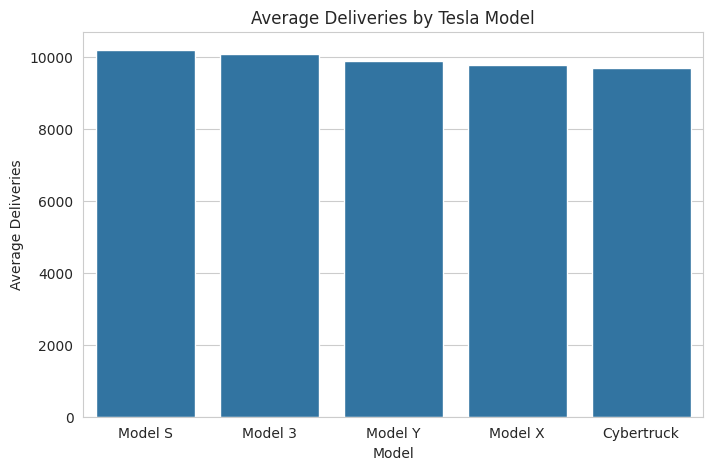

In [10]:
model_deliveries = (
    df.groupby("Model")["Estimated_Deliveries"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=model_deliveries.index,
    y=model_deliveries.values
)

plt.title("Average Deliveries by Tesla Model")
plt.xlabel("Model")
plt.ylabel("Average Deliveries")

plt.show()

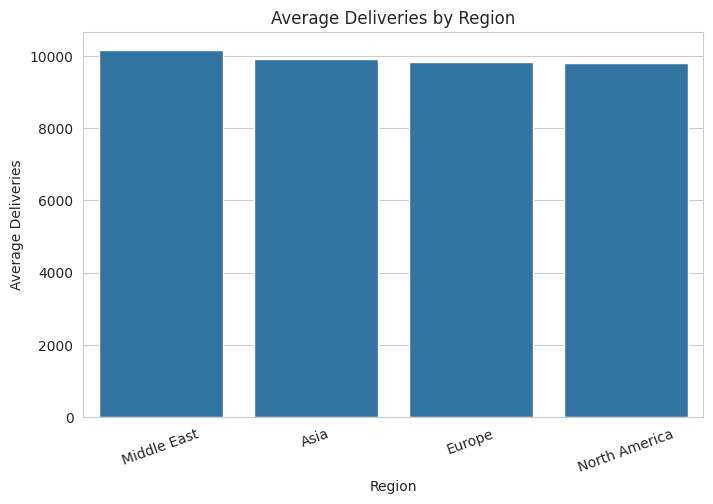

In [11]:
region_deliveries = (
    df.groupby("Region")["Estimated_Deliveries"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=region_deliveries.index,
    y=region_deliveries.values
)

plt.title("Average Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Average Deliveries")

plt.xticks(rotation=20)

plt.show()

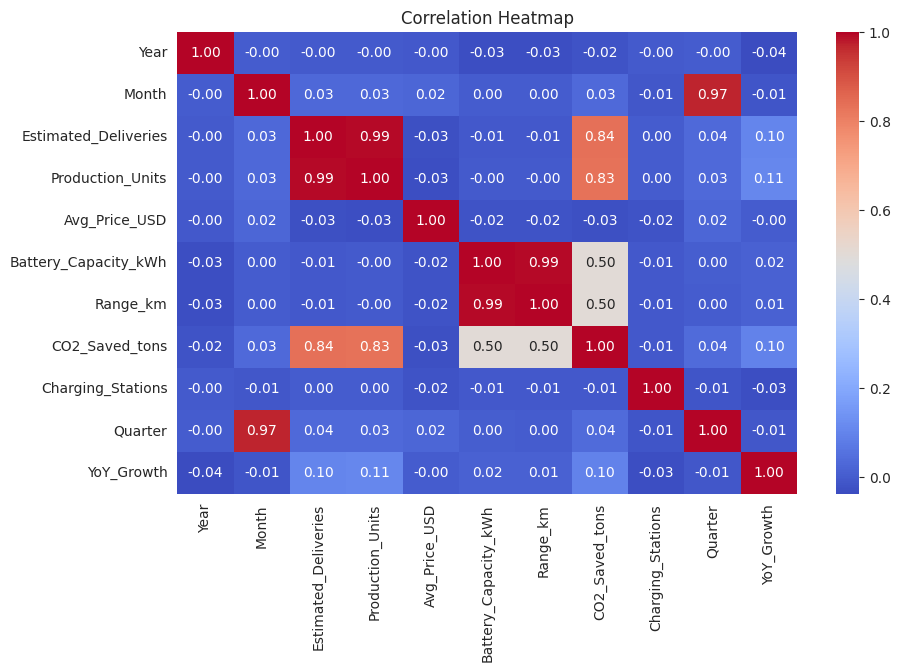

In [12]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

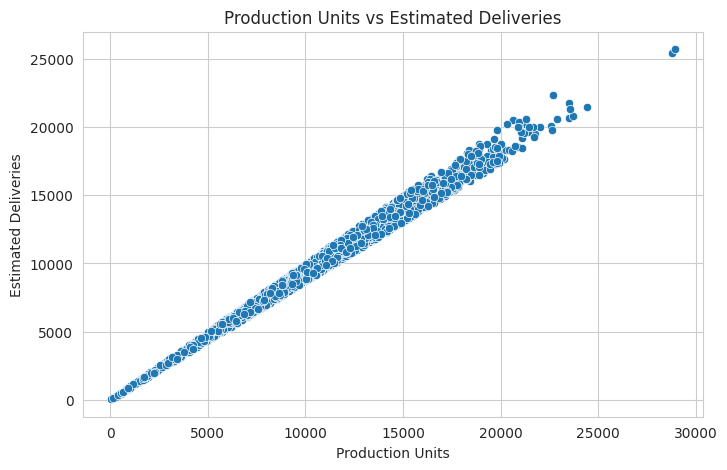

In [13]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Production_Units",
    y="Estimated_Deliveries"
)

plt.title("Production Units vs Estimated Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")

plt.show()

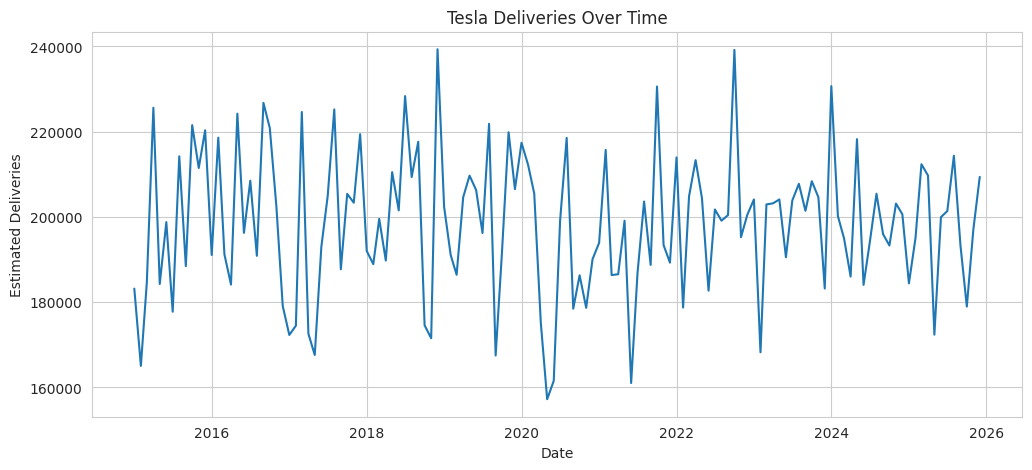

In [14]:
monthly_sales = (
    df.groupby("Date")["Estimated_Deliveries"]
      .sum()
)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values
)

plt.title("Tesla Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.grid(True)

plt.show()

In [16]:
print(
    df[
        [
            "Estimated_Deliveries",
            "Production_Units"
        ]
    ].describe().round(2)
)

       Estimated_Deliveries  Production_Units
count               2640.00           2640.00
mean                9922.20          10655.85
std                 3935.95           4260.60
min                   48.00             50.00
25%                 7292.00           7828.25
50%                 9857.00          10546.50
75%                12510.25          13469.00
max                25704.00          28939.00


# Feature Engineering

Feature engineering was used to transform raw data into informative features for machine learning. This included encoding categorical variables, creating lag features, calculating rolling statistics, and generating delivery-based metrics to improve predictive performance.

In [17]:
print("Feature Engineering")
print("-" * 50)

fe = df.copy()

encoder = LabelEncoder()

for col in ["Region", "Model", "Source_Type"]:
    fe[col] = encoder.fit_transform(fe[col])

fe = fe.sort_values(["Year", "Month"])

fe["Deliveries_Lag1"] = (
    fe["Estimated_Deliveries"]
    .shift(1)
)

fe["Deliveries_Lag2"] = (
    fe["Estimated_Deliveries"]
    .shift(2)
)

fe["Deliveries_Lag4"] = (
    fe["Estimated_Deliveries"]
    .shift(4)
)

fe["Production_Lag1"] = (
    fe["Production_Units"]
    .shift(1)
)

fe["Rolling_Mean_3"] = (
    fe["Estimated_Deliveries"]
    .shift(1)
    .rolling(3)
    .mean()
)

fe["Rolling_Std_3"] = (
    fe["Estimated_Deliveries"]
    .shift(1)
    .rolling(3)
    .std()
)

fe["Delivery_Rate"] = (
    fe["Estimated_Deliveries"]
    /
    fe["Production_Units"]
)

fe["QoQ_Growth"] = (
    fe["Estimated_Deliveries"]
    .pct_change()
)

fe = fe.fillna(method="bfill")

print("Feature Engineering Completed")
print("Shape:", fe.shape)

fe.head()

Feature Engineering
--------------------------------------------------
Feature Engineering Completed
Shape: (2640, 23)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,...,Quarter,YoY_Growth,Deliveries_Lag1,Deliveries_Lag2,Deliveries_Lag4,Production_Lag1,Rolling_Mean_3,Rolling_Std_3,Delivery_Rate,QoQ_Growth
0,2015,1,0,4,12446,13885,55183.13,60,340,634.75,...,1,-29.334726,12446.0,12446.0,12446.0,13885.0,10898.333333,1882.237056,0.896363,-0.080347
1,2015,1,2,1,11446,12752,89289.40,100,588,1009.54,...,1,-29.334726,12446.0,12446.0,12446.0,13885.0,10898.333333,1882.237056,0.897585,-0.080347
2,2015,1,2,0,8803,9344,102888.58,60,336,443.67,...,1,-29.334726,11446.0,12446.0,12446.0,12752.0,10898.333333,1882.237056,0.942102,-0.230910
3,2015,1,3,0,6367,6802,104962.32,82,459,438.37,...,1,-29.334726,8803.0,11446.0,12446.0,9344.0,10898.333333,1882.237056,0.936048,-0.276724
4,2015,1,0,1,8795,9165,87988.73,82,456,601.58,...,1,-29.334726,6367.0,8803.0,12446.0,6802.0,8872.000000,2540.202945,0.959629,0.381341


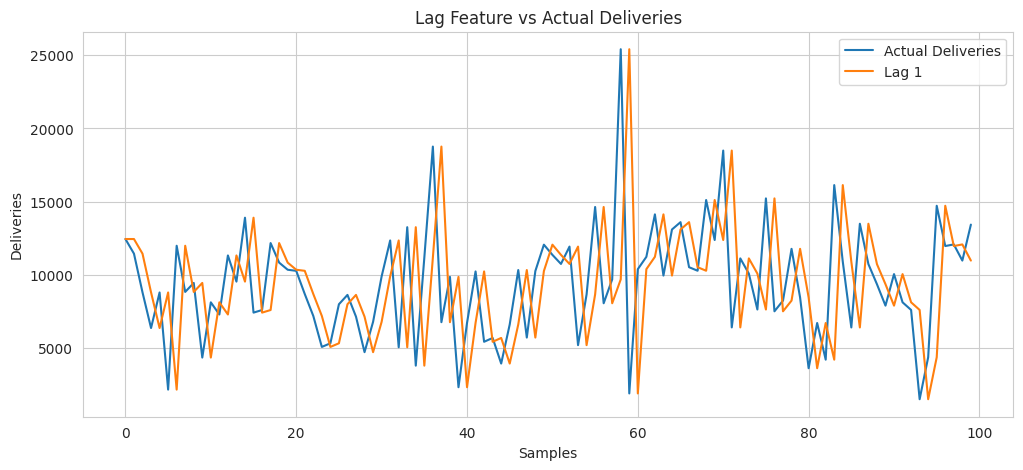

In [18]:
plt.figure(figsize=(12,5))

sample = fe.head(100)

plt.plot(
    sample["Estimated_Deliveries"],
    label="Actual Deliveries"
)

plt.plot(
    sample["Deliveries_Lag1"],
    label="Lag 1"
)

plt.title("Lag Feature vs Actual Deliveries")

plt.xlabel("Samples")
plt.ylabel("Deliveries")

plt.legend()

plt.show()

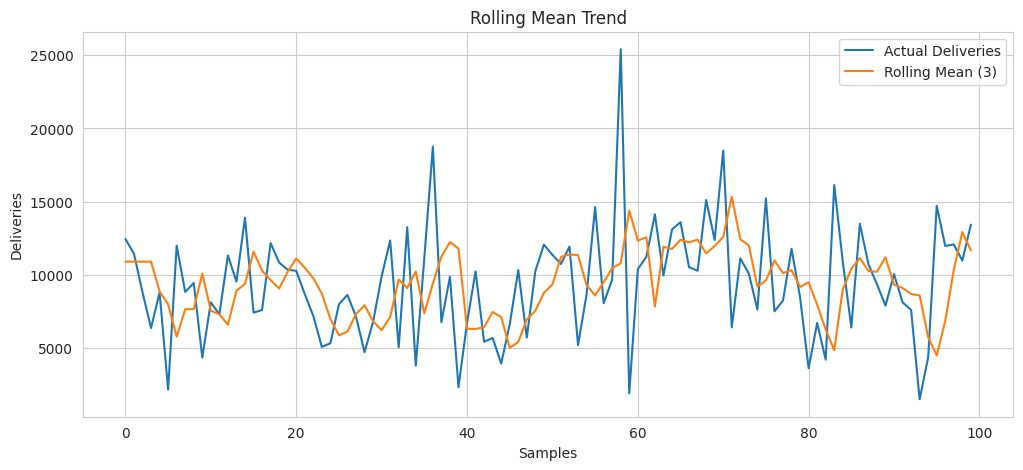

In [19]:
plt.figure(figsize=(12,5))

sample = fe.head(100)

plt.plot(
    sample["Estimated_Deliveries"],
    label="Actual Deliveries"
)

plt.plot(
    sample["Rolling_Mean_3"],
    label="Rolling Mean (3)"
)

plt.title("Rolling Mean Trend")

plt.xlabel("Samples")
plt.ylabel("Deliveries")

plt.legend()

plt.show()

In [20]:
TARGET = "Estimated_Deliveries"

FEATURES = [
    col
    for col in fe.columns
    if col not in ["Estimated_Deliveries", "Date"]
]

print("Target:", TARGET)
print("Number of Features:", len(FEATURES))

Target: Estimated_Deliveries
Number of Features: 21


In [26]:
X = fe[FEATURES]
y = fe[TARGET]

split_index = int(len(fe) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train Size:", len(X_train))
print("Test Size :", len(X_test))

Train Size: 2112
Test Size : 528


In [27]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(2112, 21)
(528, 21)
(2112,)
(528,)


# Model Training

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
print("Model Training")
print("-" * 50)

pipe_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipe_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10))
])

pipe_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=1, max_iter=5000))
])

pipe_elastic = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(
        alpha=1,
        l1_ratio=0.5,
        max_iter=5000
    ))
])

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    random_state=42
)

models = {
    "Linear Regression": pipe_linear,
    "Ridge": pipe_ridge,
    "Lasso": pipe_lasso,
    "ElasticNet": pipe_elastic,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append([
        name,
        round(mae, 2),
        round(rmse, 2),
        round(r2, 4)
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]
)

results_df.sort_values(
    by="R2",
    ascending=False
)

Model Training
--------------------------------------------------


,Model,MAE,RMSE,R2
5,Gradient Boosting,58.89,77.74,0.9995
4,Random Forest,64.04,98.99,0.9993
2,Lasso,106.44,151.11,0.9983
0,Linear Regression,105.91,150.51,0.9983
1,Ridge,109.12,160.71,0.9981
3,ElasticNet,738.38,944.53,0.9329


# Model Evaluation

In [30]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import (
    train_test_split,
    KFold,
    TimeSeriesSplit,
    cross_val_score,
    GridSearchCV
)
print("Model Evaluation")
print("-" * 50)

tscv = TimeSeriesSplit(n_splits=5)

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=tscv,
        scoring="r2"
    )

    print(
        f"{name}: "
        f"Mean R² = {scores.mean():.4f}, "
        f"Std = {scores.std():.4f}"
    )

Model Evaluation
--------------------------------------------------
Linear Regression: Mean R² = 0.9985, Std = 0.0002
Ridge: Mean R² = 0.9972, Std = 0.0011
Lasso: Mean R² = 0.9985, Std = 0.0002
ElasticNet: Mean R² = 0.9316, Std = 0.0051
Random Forest: Mean R² = 0.9966, Std = 0.0024
Gradient Boosting: Mean R² = 0.9986, Std = 0.0008


In [31]:
print(models.keys())

dict_keys(['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet', 'Random Forest', 'Gradient Boosting'])


In [32]:
best_model = GradientBoostingRegressor(
    n_estimators=200,
    random_state=42
)

best_model.fit(
    X_train,
    y_train
)

best_predictions = best_model.predict(
    X_test
)

In [33]:
mae = mean_absolute_error(
    y_test,
    best_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        best_predictions
    )
)

r2 = r2_score(
    y_test,
    best_predictions
)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

MAE : 58.89
RMSE: 77.74
R²  : 0.9995


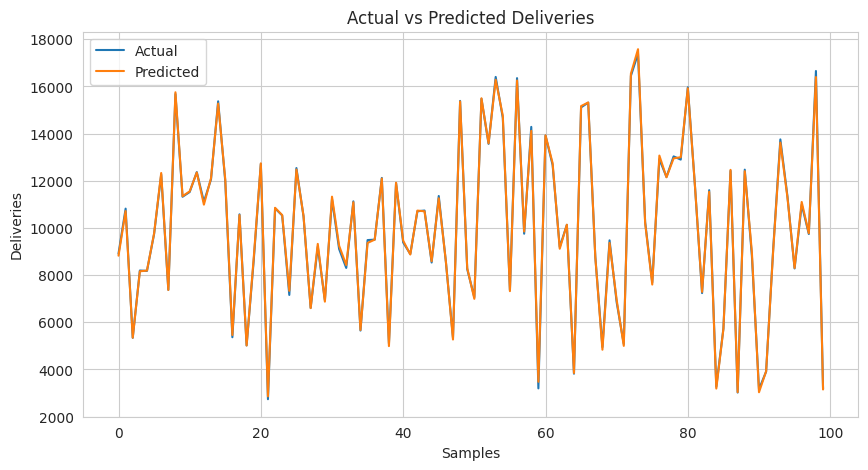

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(
    y_test.values[:100],
    label="Actual"
)

plt.plot(
    best_predictions[:100],
    label="Predicted"
)

plt.title("Actual vs Predicted Deliveries")

plt.xlabel("Samples")
plt.ylabel("Deliveries")

plt.legend()

plt.show()

# Cross Validation

In [40]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

print("Cross Validation")
print("-" * 50)

tscv = TimeSeriesSplit(n_splits=5)

cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=tscv,
    scoring="r2"
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage R²:")
print(round(cv_scores.mean(), 4))

Cross Validation
--------------------------------------------------
Cross Validation Scores:
[0.99703881 0.99860029 0.99897293 0.99897767 0.9994084 ]

Average R²:
0.9986


# Hyperparameter Tuning

In [35]:
print("Hyperparameter Tuning")
print("-" * 50)

rf = RandomForestRegressor(
    random_state=42
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None]
}

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

print("Best Parameters:")
print(grid_search.best_params_)

best_rf = grid_search.best_estimator_

Hyperparameter Tuning
--------------------------------------------------
Best Parameters:
{'max_depth': 10, 'n_estimators': 200}


# Time Series Forecasting

In [41]:
from statsmodels.tsa.arima.model import ARIMA

ts = (
    df.groupby("Date")["Estimated_Deliveries"]
      .sum()
)

model = ARIMA(
    ts,
    order=(1, 1, 1)
)

arima_model = model.fit()

forecast = arima_model.forecast(
    steps=6
)

print("Next 6 Period Forecast")
print(forecast)

Next 6 Period Forecast
2026-01-01    201130.711312
2026-02-01    199815.368230
2026-03-01    199605.917024
2026-04-01    199572.564655
2026-05-01    199567.253726
2026-06-01    199566.408030
Freq: MS, Name: predicted_mean, dtype: float64


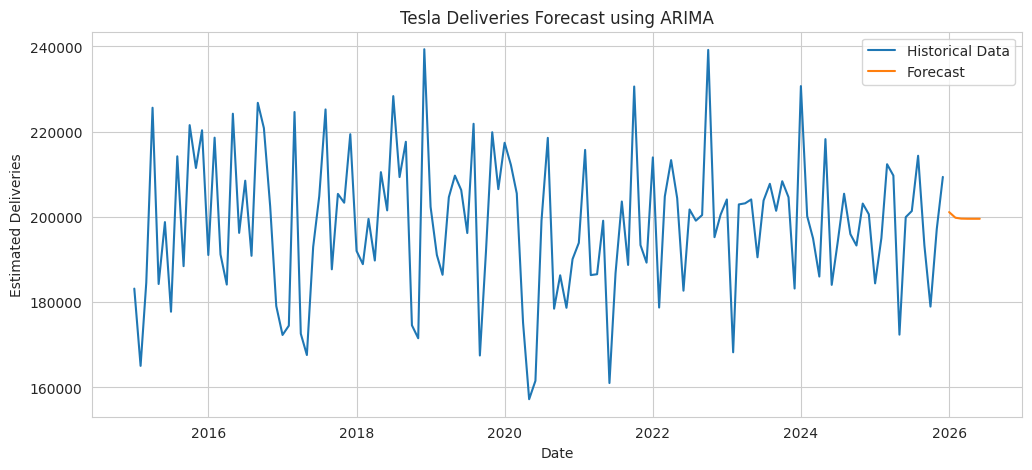

In [42]:
plt.figure(figsize=(12, 5))

plt.plot(
    ts.index,
    ts.values,
    label="Historical Data"
)

plt.plot(
    forecast.index,
    forecast.values,
    label="Forecast"
)

plt.title("Tesla Deliveries Forecast using ARIMA")

plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.legend()

plt.show()

In [39]:
print("Checking Pipelines")
print("-" * 50)

for name, model in models.items():

    print(f"\n{name}")

    print("Type:", type(model))

    if hasattr(model, "named_steps"):
        print("Pipeline Steps:")
        print(model.named_steps)

        try:
            preds = model.predict(X_test[:5])
            print("Prediction Test: Success")
            print("Sample Predictions:", preds[:3])
        except:
            print("Prediction Test: Model not fitted")

    else:
        print("Not a Pipeline (Tree Model)")

        try:
            preds = model.predict(X_test[:5])
            print("Prediction Test: Success")
            print("Sample Predictions:", preds[:3])
        except:
            print("Prediction Test: Model not fitted")

Checking Pipelines
--------------------------------------------------

Linear Regression
Type: <class 'sklearn.pipeline.Pipeline'>
Pipeline Steps:
{'scaler': StandardScaler(), 'model': LinearRegression()}
Prediction Test: Success
Sample Predictions: [ 8892.6686113  10802.13667848  5276.11348326]

Ridge
Type: <class 'sklearn.pipeline.Pipeline'>
Pipeline Steps:
{'scaler': StandardScaler(), 'model': Ridge(alpha=10)}
Prediction Test: Success
Sample Predictions: [ 8929.17520486 10778.35384061  5388.22317746]

Lasso
Type: <class 'sklearn.pipeline.Pipeline'>
Pipeline Steps:
{'scaler': StandardScaler(), 'model': Lasso(alpha=1, max_iter=5000)}
Prediction Test: Success
Sample Predictions: [ 8886.46884422 10791.87808837  5267.13353283]

ElasticNet
Type: <class 'sklearn.pipeline.Pipeline'>
Pipeline Steps:
{'scaler': StandardScaler(), 'model': ElasticNet(alpha=1, max_iter=5000)}
Prediction Test: Success
Sample Predictions: [ 9133.79738506 10428.44127829  6717.02015334]

Random Forest
Type: <class '

#  Conclusion

An end-to-end machine learning pipeline was developed for Tesla delivery prediction, covering data preprocessing, exploratory analysis, feature engineering, model training, evaluation, and forecasting.

Among all models, Gradient Boosting Regressor achieved the best performance with an R² score of 0.9995, demonstrating excellent predictive capability.